In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df_viz = pd.read_csv("processed_data/NVDA_cleaned_data.csv")
df_viz['Close'] = pd.to_numeric(df_viz['Close'], errors='coerce')
df_viz['Volume'] = pd.to_numeric(df_viz['Volume'], errors='coerce')
df_viz.dropna(subset=['Close'], inplace=True)

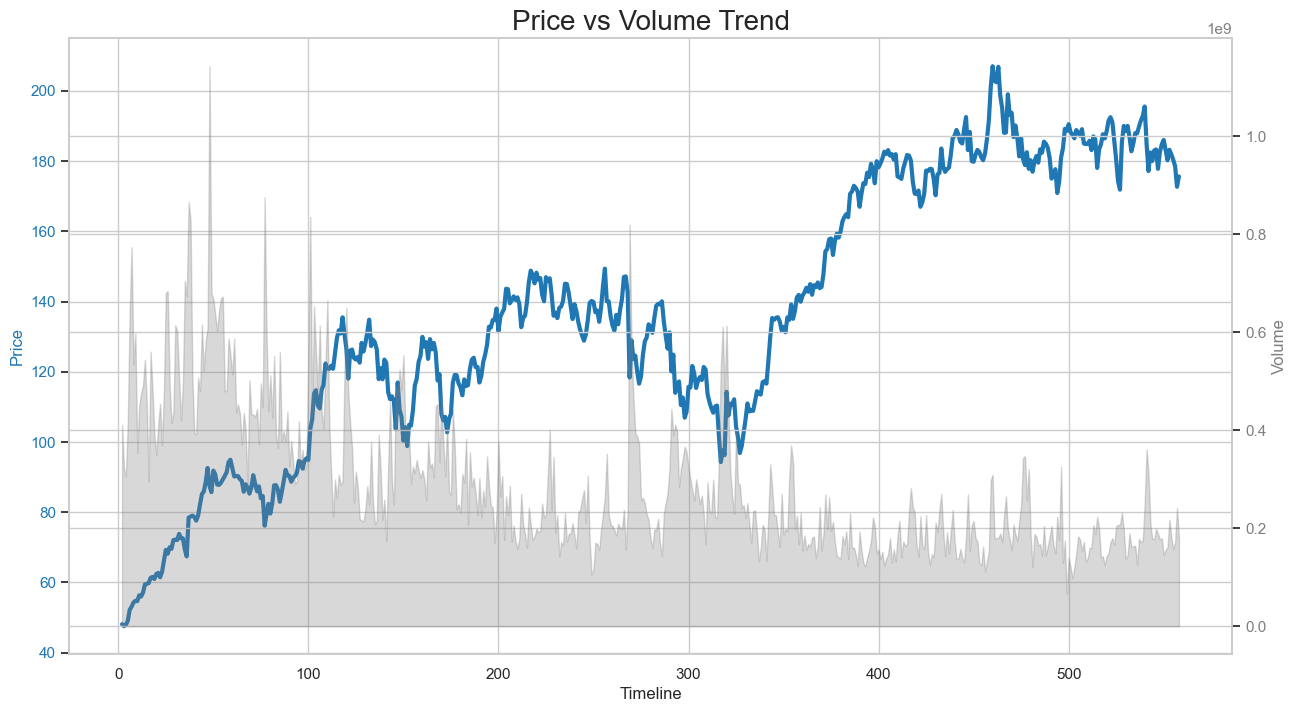

In [2]:
fig, ax1 = plt.subplots(figsize=(15, 8))

ax1.set_xlabel('Timeline')
ax1.set_ylabel('Price', color='tab:blue')
ax1.plot(df_viz.index, df_viz['Close'], color='tab:blue', linewidth=3)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx() 
ax2.set_ylabel('Volume', color='tab:gray')
ax2.fill_between(df_viz.index, df_viz['Volume'], color='tab:gray', alpha=0.3)
ax2.tick_params(axis='y', labelcolor='tab:gray')

plt.title('Price vs Volume Trend', fontsize=20)
plt.show()

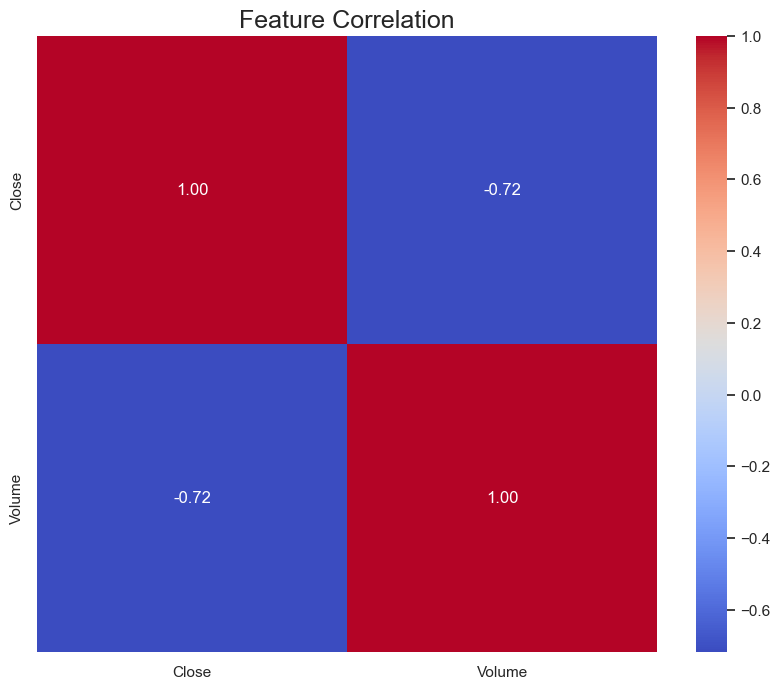

In [3]:
plt.figure(figsize=(10, 8))
numeric_only = df_viz.select_dtypes(include=[np.number])
corr_matrix = numeric_only.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation', fontsize=18)
plt.show()

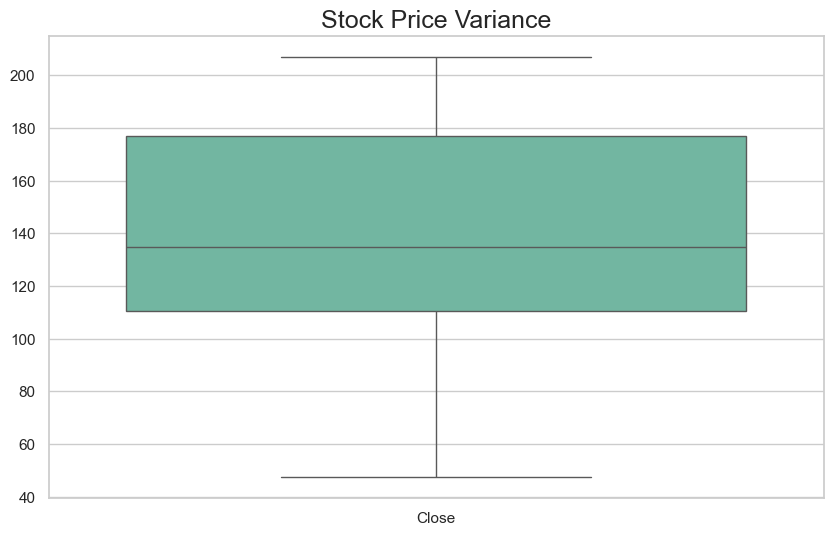

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_viz[['Open', 'High', 'Low', 'Close']], palette="Set2")
plt.title('Stock Price Variance', fontsize=18)
plt.show()

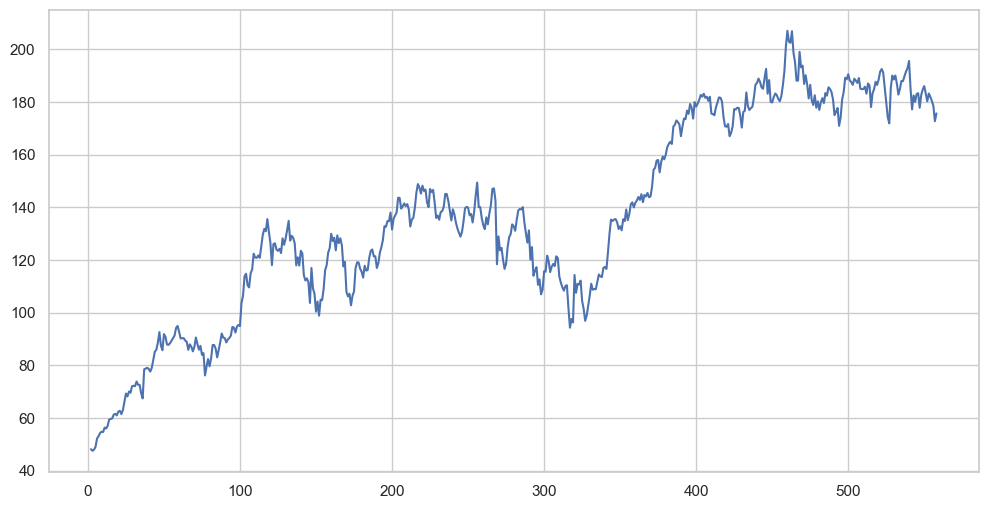

In [5]:
if not os.path.exists("visuals"):
    os.makedirs("visuals")

plt.figure(figsize=(12, 6))
plt.plot(df_viz['Close'])
plt.savefig("visuals/final_report_chart.png")